In [38]:
import tensorflow as tf

tf.__version__

'2.19.0'

In [39]:
import numpy as np
np.set_printoptions(suppress=True, precision=2)


In [40]:
from tensorflow import keras
from tensorflow.keras import layers

In [41]:
# Download the dataset
import pandas as  pd
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']



dataset = pd.read_csv(url, names=column_names,  na_values='?',  skipinitialspace=True, comment='\t', sep=' ')

In [42]:
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [43]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [44]:
dataset = dataset.dropna()

In [45]:
dataset["Origin"].value_counts()

Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [46]:
dataset["Origin"] = dataset["Origin"].map({1:"USA", 2:"Europe", 3:"Japan"})

/var/folders/c7/z9xcy1l1481bm3hgrydzvlxm0000gn/T/ipykernel_80818/121898868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Origin"] = dataset["Origin"].map({1:"USA", 2:"Europe", 3:"Japan"})


In [47]:
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,USA
394,44.0,4,97.0,52.0,2130.0,24.6,82,Europe
395,32.0,4,135.0,84.0,2295.0,11.6,82,USA
396,28.0,4,120.0,79.0,2625.0,18.6,82,USA


In [48]:
# one hot encodinh for origin

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep='')

In [49]:
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True


In [50]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

In [53]:
len(train_dataset), len(test_dataset)

(314, 78)

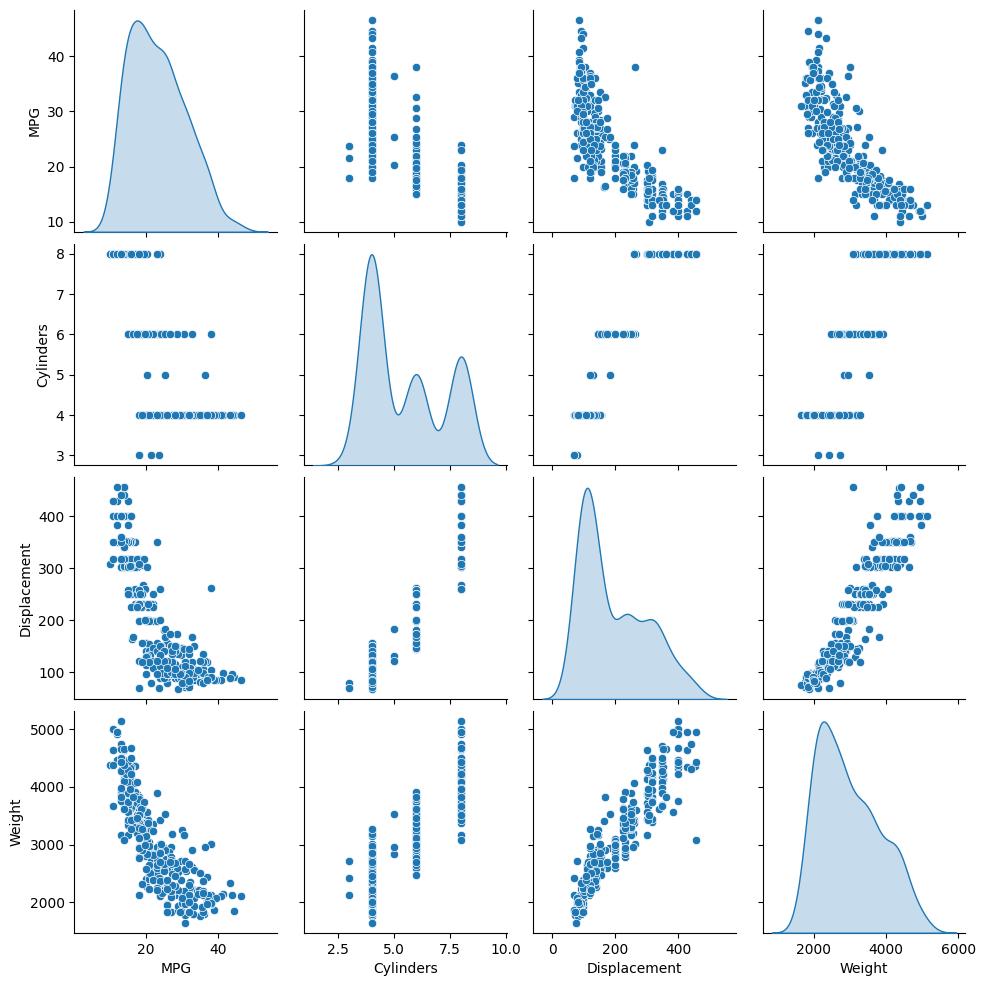

In [61]:
import seaborn as sns


sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')

In [65]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [68]:
train_dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
146,28.0,4,90.0,75.0,2125.0,14.5,74,False,False,True
282,22.3,4,140.0,88.0,2890.0,17.3,79,False,False,True
69,12.0,8,350.0,160.0,4456.0,13.5,72,False,False,True
378,38.0,4,105.0,63.0,2125.0,14.7,82,False,False,True
331,33.8,4,97.0,67.0,2145.0,18.0,80,False,True,False
...,...,...,...,...,...,...,...,...,...,...
281,19.8,6,200.0,85.0,2990.0,18.2,79,False,False,True
229,16.0,8,400.0,180.0,4220.0,11.1,77,False,False,True
150,26.0,4,108.0,93.0,2391.0,15.5,74,False,True,False
145,32.0,4,83.0,61.0,2003.0,19.0,74,False,True,False


In [69]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

In [74]:
train_features

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
146,4,90.0,75.0,2125.0,14.5,74,False,False,True
282,4,140.0,88.0,2890.0,17.3,79,False,False,True
69,8,350.0,160.0,4456.0,13.5,72,False,False,True
378,4,105.0,63.0,2125.0,14.7,82,False,False,True
331,4,97.0,67.0,2145.0,18.0,80,False,True,False
...,...,...,...,...,...,...,...,...,...
281,6,200.0,85.0,2990.0,18.2,79,False,False,True
229,8,400.0,180.0,4220.0,11.1,77,False,False,True
150,4,108.0,93.0,2391.0,15.5,74,False,True,False
145,4,83.0,61.0,2003.0,19.0,74,False,True,False


In [78]:
train_dataset.describe().transpose()[["mean","std"]]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [81]:
normlaizer = tf.keras.layers.Normalization(axis=-1)

np.array(train_features)

array([[4, 90.0, 75.0, ..., False, False, True],
       [4, 140.0, 88.0, ..., False, False, True],
       [8, 350.0, 160.0, ..., False, False, True],
       ...,
       [4, 108.0, 93.0, ..., False, True, False],
       [4, 83.0, 61.0, ..., False, True, False],
       [4, 107.0, 86.0, ..., True, False, False]], dtype=object)

In [83]:
normlaizer.adapt(np.array(train_features))

In [85]:
print(normlaizer.mean.numpy())

[[   5.48  195.32  104.87 2990.25   15.56   75.9     0.18    0.2     0.62]]


In [92]:
first = np.array(train_features[:1], dtype=float)
first

array([[   4. ,   90. ,   75. , 2125. ,   14.5,   74. ,    0. ,    0. ,
           1. ]])

In [93]:
with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normlaizer(first).numpy())

First example: [[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

Normalized: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


In [94]:
horsepower = np.array(train_features['Horsepower'])

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)

/Users/sachinmurali/anaconda3/envs/tensorflows/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [95]:
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [96]:
horsepower_model.predict(horsepower[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[-0.34],
       [-0.19],
       [ 0.64],
       [-0.48],
       [-0.44],
       [-0.17],
       [-0.52],
       [-0.44],
       [-0.11],
       [-0.19]], dtype=float32)

In [97]:
horsepower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [98]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    # Suppress logging.
    verbose=0,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

CPU times: user 2.78 s, sys: 273 ms, total: 3.06 s
Wall time: 2.75 s


In [99]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,3.802197,4.193362,95
96,3.803176,4.193794,96
97,3.804144,4.202336,97
98,3.808487,4.171430,98
99,3.804358,4.192134,99


In [101]:
import matplotlib.pyplot as plt
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)
  

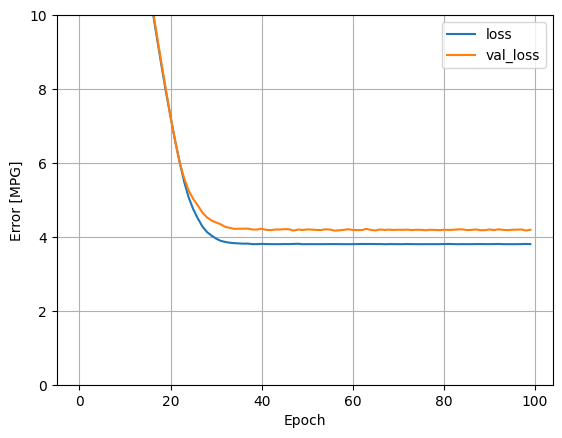

In [102]:
plot_loss(history)

In [103]:
test_results = {}

test_results['horsepower_model'] = horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels, verbose=0)

In [104]:
x = tf.linspace(0.0, 250, 251)
y = horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [105]:
def plot_horsepower(x, y):
  plt.scatter(train_features['Horsepower'], train_labels, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Horsepower')
  plt.ylabel('MPG')
  plt.legend()

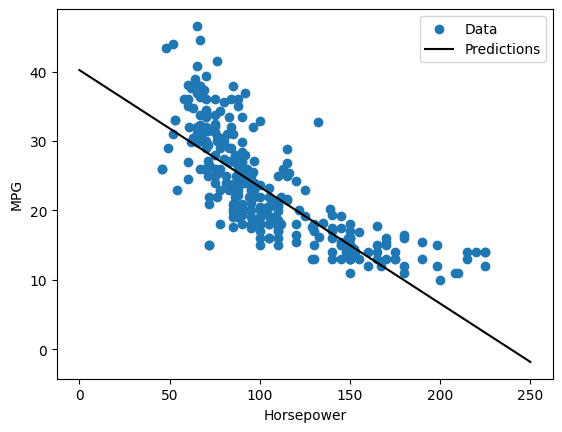

In [106]:
plot_horsepower(x, y)

In [ ]:
# Embeddings: 
   # Represenattion of data in numerical format
   # its represent dat in contious vector space
   # Its stores the data in dense vector format unlike one-hot
# Types of embedding 
# word , sentence, image embedidng , document embdding
# Advantge :  simlilarity search


# 2015 - google search  - keyword search
# now - semanatic search

# famous place with natite 

# Word Embedding - imdb review ,  +ve or _ve

# Training Data

# The movie is awesome  --> +ve
# The film is amazing  --- > +ve
# The movie is not good ---> -ve
# really bad ---> -ve


# Preprocess
# The movie is awesome -- toenkization  --> [The ,movie ,is ,awesome] ---> [0,1,2,3]  --> 1 , 0
# # The film is amazing  [0, 4, 2 ,5] --- > +ve

# model -- Embeddlayer , Dense

# EmbedLayer
       # input : [0,1,2,3]  --- > 1
       # random iniotailize Dense vector created





In [ ]:
_ve                   +ve ([0,1,2,3])  0, 4, 2 ,5] 

200200



 